# What Makes a YouTube Video Go Viral?


Fall 2024 Data Science Project

Colin Galen (working alone)

Contributions: I worked alone, so I did everything

# Introduction

The core question we'll attempt to answer here is: **what makes a YouTube video good**? This is a question in high demand - being able to make successful videos yields both prestige/popularity and a potential lot of money to its creator(s), though the definition of "good" varies by person. Of course, this is an incredibly complex question without an exact solution, but we'll see what insights on it can be uncovered by methods in data science.

From a scientific perspective, we'll define "good" by the number of views the video gets, as that usually correlates directly with many desirable parts of a video (watch time, likes/comments/engagement, revenue, relevance/overall success). Then, the question becomes: what are the common elements of high-view videos?

Here, we'll take a dataset of trending videos (i.e. videos that showed some degree of success) and attempt to find patterns and look for common elements of these (somewhat) successful videos. Since the dataset also includes the direct view count, we'll also look for factors that distinguish the higher view videos from the rest within the dataset itself.

# Data Curation

*For the rest of the tutorial: YT = YouTube*

Let's look into the dataset:
https://www.kaggle.com/datasets/datasnaek/youtube-new/data?select=USvideos.csv

A quick look shows that this dataset contains two types of files: for various countries, it has a .csv file with various bits of YT metadata for many different trending videos, and a .json file pertaining to decoding the meaning of video category IDs.

We should note here that the dataset has videos from 2017-2018, which is fairly old by YT standards, but since the source code for data collection is public, this can fairly easily be replicated for more modern trending videos if some useful insights are found.

Let's dive into the data!

We'll start with some imports we'll be using.

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json
import scipy.stats as sci
import numpy as np

import warnings
warnings.simplefilter('ignore', pd.errors.SettingWithCopyWarning)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from os import path

Now, we can set up the dataset - Kaggle has a handy API for downloading a dataset, so we'll just invoke that and save its path for our use.

In [2]:
data_path = kagglehub.dataset_download("datasnaek/youtube-new")

100%|██████████| 201M/201M [00:01<00:00, 147MB/s]

Extracting files...


We noted before that there are two types of files - main dataset files for various countries and a JSON describing what the video category IDs mean for each country. We'll set up some basic functions to create those file paths for reading.

In [3]:
# JP, KR, MX, and RU excluded because of unicode errors with file reading
countries = ['CA', 'DE', 'FR', 'GB', 'IN', 'US']

def main_pathname(country):
  return path.join(data_path, country + 'videos.csv')

def category_pathname(country):
  return path.join(data_path, country + '_category_id.json')

With that, we'll set up some Pandas dataframes for each country.

In [4]:
dfs = {}
for country in countries:
  dfs[country] = pd.read_csv(main_pathname(country))

Let's quickly look into the US data so we can see exactly what we're working with.

In [5]:
dfs['US'].head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


Since we have many different countries, we'll set up a general function to do the same preprocessing for every dataframe.

In this function, we'll:
*   Parse the two data columns (`trending_date` and `publish_time`) into a format Pandas can work with.
*   Convert the category IDs in each dataframe into text format. Unfortunately, video categories in the dataset have only numerical IDs, which correspond to different categories between different countries (e.g. US's ID 7 means something different from CA's 7). For this to be any useful, we'll have to replace the IDs with the actual categories they represent.

Then, we can simply call the function for each country's dataframe, and look again at the US data for a quick sanity check that everything worked:

In [6]:
def preprocess_df(country, df):
  # parse the two date columns
  df['trending_date'] = pd.to_datetime(df['trending_date'], format = '%y.%d.%m')
  df['publish_time'] = pd.to_datetime(df['publish_time'], format = '%Y-%m-%dT%H:%M:%S.%fZ')

  # relabel the category IDs to their text labels
  with open(category_pathname(country)) as f: # open the .json file
    cat = json.load(f)

  def find_category(id): # a quick function to grab the text label from a category ID (not straightforward because of their format)
    for item in cat['items']:
      if str(id) == item['id']:
        return item['snippet']['title']

  df['category_id'] = df['category_id'].apply(find_category)

for country in countries:
  preprocess_df(country, dfs[country])

dfs['US'].head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,People & Blogs,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,Entertainment,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,Comedy,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,Entertainment,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,Entertainment,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


# Exploratory Data Analysis

Now, we can look into the dataset itself. I personally am most interested in US-based videos, so we'll start with that dataset and see how useful the other countries can be later on. Let's check for missing values, and see how many unique videos are actually here.

In [7]:
print(dfs['US'].count())
print("Dataset shape: ", dfs['US'].shape)
print('Unique videos: ' + str(len(dfs['US']['video_id'].unique())))

video_id                  40949
trending_date             40949
title                     40949
channel_title             40949
category_id               40949
publish_time              40949
tags                      40949
views                     40949
likes                     40949
dislikes                  40949
comment_count             40949
thumbnail_link            40949
comments_disabled         40949
ratings_disabled          40949
video_error_or_removed    40949
description               40379
dtype: int64
Dataset shape:  (40949, 16)
Unique videos: 6351


Except for some missing (or just empty, which is a valid possibility) descriptions, all the data are intact!

Out of almost 41 thousand entries, there are only about 6 thousand unique videos. Let's plot the distribution of frequencies:

Text(0.5, 1.0, 'Distribution of Per-Video Frequency in Dataset')

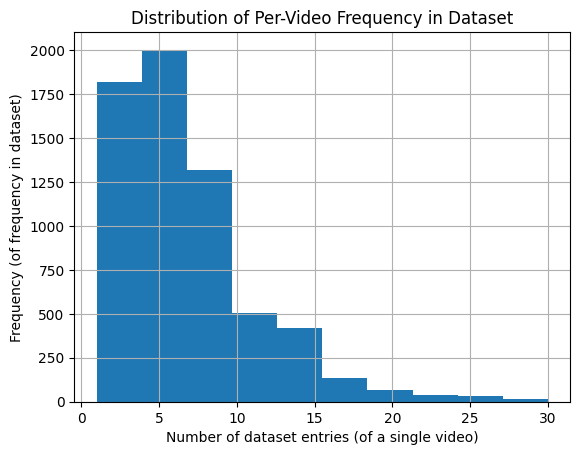

In [8]:
dfs['US']['video_id'].value_counts().hist()
plt.xlabel('Number of dataset entries (of a single video)')
plt.ylabel('Frequency (of frequency in dataset)')
plt.title('Distribution of Per-Video Frequency in Dataset')

and we see that no single video appears more than 30 times, while the majority of videos appear more than 5.

It's hard to tell if multiple occurrences of a video should be condensed into a single occurrence.

If a video is on the trending tab for a while (thus representing multiple data points), it can be argued that it deserves more weight, as it's more prominent on the trending tab. Alternatively, videos could be condensed into the mean/etc. of their numerical statistics (like views and trending dates), with an extra number for its frequency.

Ultimately, it would depend on what exactly we ask of the data. For the sake of exploring, let's leave it as-is and see what comes out of it.

To continue looking into the nature of the data, let's look at some basic summary statistics.

In [9]:
dfs['US'].describe()

,trending_date,publish_time,views,likes,dislikes,comment_count
count,40949,40949,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,2018-02-27 06:22:42.494810624,2018-02-11 01:00:49.258589952,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
min,2017-11-14 00:00:00,2006-07-23 08:24:11,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2018-01-04 00:00:00,2017-12-27 21:00:00,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,2018-02-26 00:00:00,2018-02-21 16:19:27,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,2018-04-24 00:00:00,2018-04-16 17:20:26,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,2018-06-14 00:00:00,2018-06-14 01:31:53,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06
std,NaN,NaN,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04


In [10]:
summary = dfs['US'].describe()
print('Avg. like/view percentage: ' + str(100 * summary['likes']['mean'] / summary['views']['mean']) + '%')
print('Avg. dislike/view percentage: ' + str(100 * summary['dislikes']['mean'] / summary['views']['mean']) + '%')
print('Avg. like/vote percentage: ' + str(100 * summary['likes']['mean'] / (summary['likes']['mean'] + summary['dislikes']['mean'])) + '%')
print('Avg. comment/view percentage: ' + str(100 * summary['comment_count']['mean'] / summary['views']['mean']) + '%')

Avg. like/view percentage: 3.1458482587194903%
Avg. dislike/view percentage: 0.1572104811580879%
Avg. like/vote percentage: 95.24045760191615%
Avg. comment/view percentage: 0.3577964523212406%


From just the means, we see some interesting YouTube-related statistics right off the bat:
- 3.15% of viewers liked the videos, on average
- 0.16% of viewers disliked, on average
- 95.2% of video votes were likes, on average
- 0.36% of viewers commented, on average

Another interesting related data point is the portion of views that led to subscriptions, but that is much harder to measure and this dataset doesn't seem to offer that. The rest of the information is still handy to measure up against though.

The standard deviations are also enormous compared to the means, indication that this dataset represents a massive range of video sizes.

Let's pivot from that, and look over what view counts look like over time by plotting the mean view count for videos from each day:

Text(0.5, 1.0, 'Daily View Averages on Trending Tab')

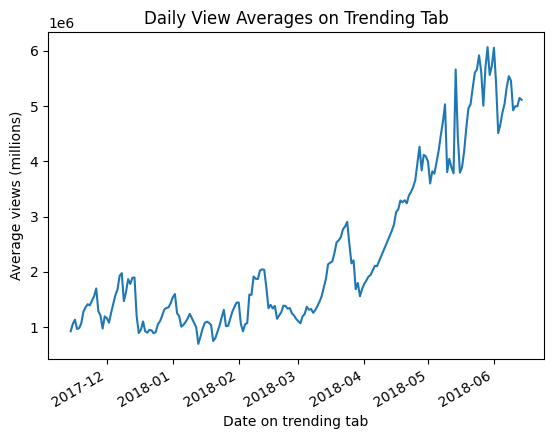

In [11]:
views_by_day = dfs['US'].groupby('trending_date')['views'].mean()
views_by_day.plot.line()
plt.xlabel('Date on trending tab')
plt.ylabel('Average views (millions)')
plt.title('Daily View Averages on Trending Tab')

We see a clear pattern - near April, the view counts spike greatly from what they were before.

There are many possible explanations for this - it could be seasonal (related to kids getting off from school in summer), or YouTube itself growing, or specific events that drew people more toward YouTube during those times.

From this dataset alone, there's probably too many possibilities to draw any specific conclusions. Unfortunately, it spans less than a year, so we can't really look into seasonal effects since there are so many other possibilities too.

Let's look into the channels that made these videos. How many are there?

In [12]:
len(dfs['US']['channel_title'].unique())

2207

Out of 6 thousand unique videos, there are 2 thousand channels contributing these trending videos. Who are they?

In [13]:
print(dfs['US']['channel_title'].value_counts().head(15))
print(dfs['US']['channel_title'].value_counts().tail(15))

channel_title
ESPN                                      203
The Tonight Show Starring Jimmy Fallon    197
TheEllenShow                              193
Vox                                       193
Netflix                                   193
The Late Show with Stephen Colbert        187
Jimmy Kimmel Live                         186
Late Night with Seth Meyers               183
Screen Junkies                            182
NBA                                       181
CNN                                       180
Saturday Night Live                       175
WIRED                                     171
BuzzFeedVideo                             169
INSIDER                                   167
Name: count, dtype: int64
channel_title
dannotv              1
WhatsApp Wacky       1
PekingDukVEVO        1
Wendy's              1
ClovesVEVO           1
Chris Sturgeon       1
The Inertia          1
Caters Clips         1
Total Combat         1
KickThePj            1
Hin Nya              1
PK 

Looking at these channel names (ordered by frequency in the dataset), most of the top channels are very large brand names with popularity outside of YouTube as well, while the lower channels seem to fit that description less.

What about how many entries each channel has? Let's look at the distribution:

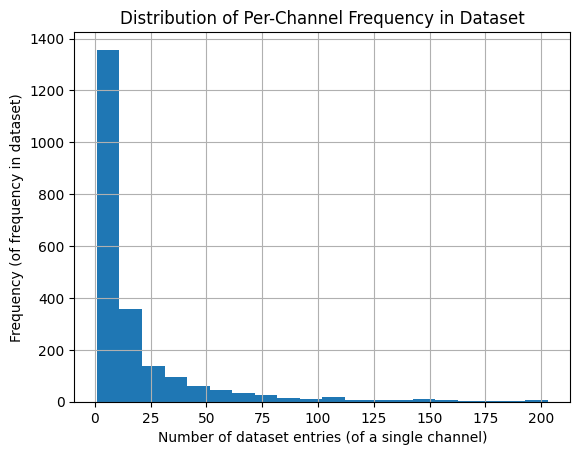

Text(0.5, 1.0, 'Boxplot of Per-Channel Frequency in Dataset')

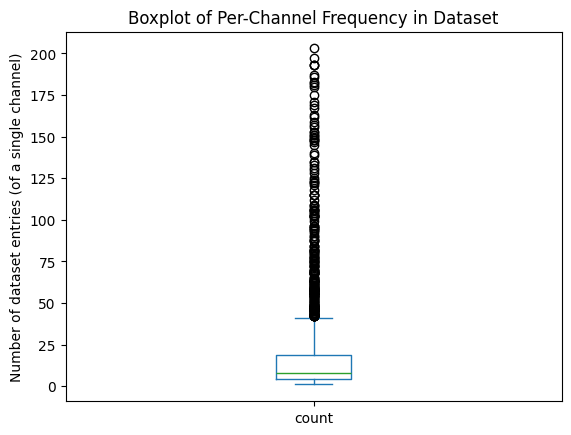

In [14]:
dfs['US']['channel_title'].value_counts().hist(bins = 20)
plt.xlabel('Number of dataset entries (of a single channel)')
plt.ylabel('Frequency (of frequency in dataset)')
plt.title('Distribution of Per-Channel Frequency in Dataset')
plt.show()

dfs['US']['channel_title'].value_counts().plot.box()
plt.ylabel('Number of dataset entries (of a single channel)')
plt.title('Boxplot of Per-Channel Frequency in Dataset')

Both plots tell us that the vast majority of channels don't have many entries in the dataset (e.g. the boxplot shows a median and even third quartile much less than 25), indicating a large variety of trending videos (and that the trending tab isn't necessarily dominated by the top dogs in the market). However, quite a few do have over 25 entries.

External popularity would be very important to any analysis of this dataset - if the popularity of a video is not isolated to YouTube, it's harder to draw conclusions from the nature of trending videos about what elements of videos work to make them successful.

This will have to be a factor in the more complex analyses we do later on. Let's look a bit more into it.

Do the more frequently appearing channels get more views? Common sense would imply yes, but... let's look anyway!

Here, we'll look at the correlation between frequency (in the dataset) and average view count (over videos in the dataset) for each channel.

Correlation (Pearson): 0.10604120235833302


Text(0.5, 1.0, 'Channel Views vs. Appearances on Trending Tab')

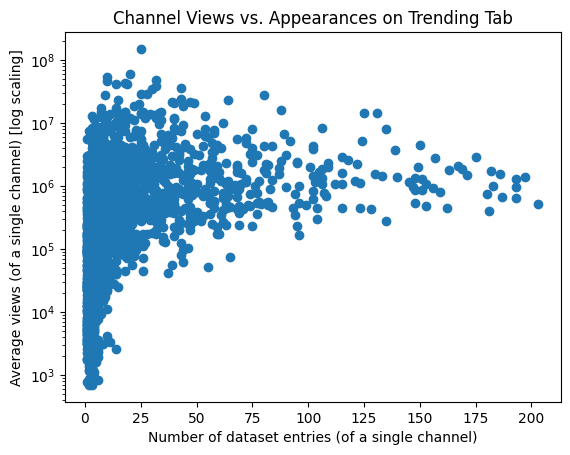

In [15]:
# create a new dataframe with per-channel average views and total (not necessarily distinct) video count
channel_views = pd.DataFrame(dfs['US'].groupby('channel_title')['views'].mean().rename('average_views'))
channel_count = pd.DataFrame(dfs['US'].groupby('channel_title')['video_id'].count().rename('video_count'))
channel_total = channel_views.join(channel_count, on = 'channel_title')

print('Correlation (Pearson): ' + str(channel_total['average_views'].corr(channel_total['video_count'])))

# create a scatter plot of avg views & video count
plt.scatter(channel_total['video_count'], channel_total['average_views'])
plt.yscale('log')
plt.xlabel('Number of dataset entries (of a single channel)')
plt.ylabel('Average views (of a single channel) [log scaling]')
plt.title('Channel Views vs. Appearances on Trending Tab')

We actually see a very weak correlation! It's clear from the shape of this graph, though, that most of the lower-view channels on the trending tab also occur infrequently.

Other than that, there is little relation between frequency on the trending tab and the average view count of such videos (relative to entire channels). We even see that the most viewed (on average) channels over the whole dataset aren't the most frequently occurring.

This may indicate that external popularity may be less relevant to view count specifically... or maybe something else! Hard to tell exactly at this point.

For curiosity's sake, let's look only into the more frequently appearing channels. Same analysis as above, but only for channels with more than 25 entries in the dataset.

Correlation (Pearson): -0.10252547124980196


Text(0.5, 1.0, 'Channel Views vs. Appearances on Trending Tab (with at least 25 entries)')

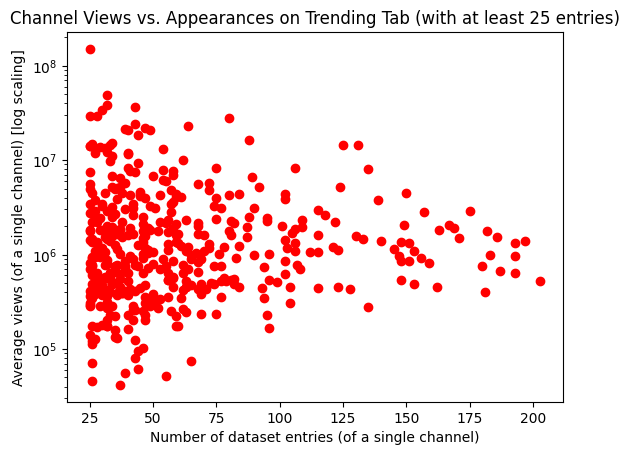

In [16]:
large_total = channel_total[channel_total['video_count'] >= 25]

print('Correlation (Pearson): ' + str(large_total['average_views'].corr(large_total['video_count'])))

plt.scatter(large_total['video_count'], large_total['average_views'], c = 'red')
plt.yscale('log')
plt.xlabel('Number of dataset entries (of a single channel)')
plt.ylabel('Average views (of a single channel) [log scaling]')
plt.title('Channel Views vs. Appearances on Trending Tab (with at least 25 entries)')

We see similar results correlation-wise (and, of course, the graphs are similar, since the only change was removing the left slice of data points).

Now, let's bring the other countries back in. For now, we'll start with Canada, and we'll look into how video categories relate across countries.

Let's compare the distributions of category IDs. Since these are categorical data, we'll use a chi-squared test, scaling CA's frequencies to have the same sum as US's.

Note that we use an inner join. This means that categories appearing in one country but not the other will be ignored. This may bias our findings a bit, but we'll see from the results that this potential bias doesn't matter.

We'll plot the distributions as well.

Power_divergenceResult(statistic=6789.7929911219635, pvalue=0.0)


,US,CA
category_id,,
Autos & Vehicles,384,353.787309
Comedy,3457,3781.415063
Education,1656,993.210264
Entertainment,9964,13481.000270
Film & Animation,2345,2064.594495
Gaming,817,1346.997574
Howto & Style,4146,2011.476287
Music,6472,3739.321389
News & Politics,2487,4168.275974


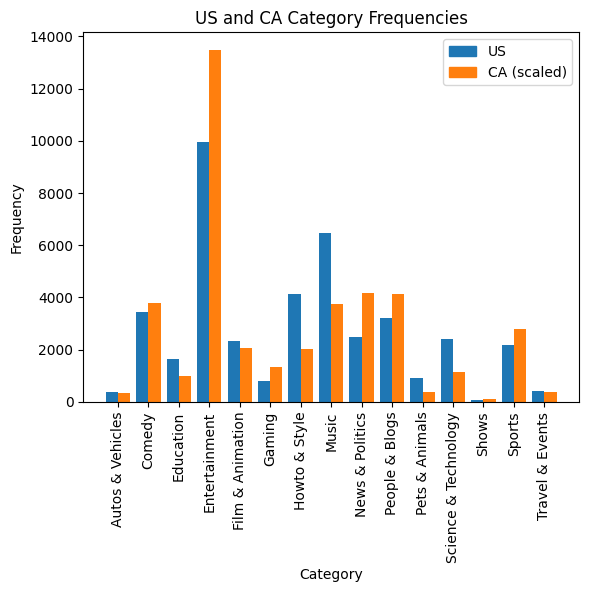

In [17]:
# get category ID counts for both countries
us_cats = pd.DataFrame(dfs['US'].groupby('category_id')['category_id'].count().rename('US'))
ca_cats = pd.DataFrame(dfs['CA'].groupby('category_id')['category_id'].count().rename('CA'))
joined_cats = us_cats.join(ca_cats, how = 'inner', on = 'category_id')

# scale CA's counts to have the same sum as US
sum_us = joined_cats['US'].sum()
sum_ca = joined_cats['CA'].sum()
joined_cats['CA'] = joined_cats['CA'] * sum_us / sum_ca

joined_df = pd.DataFrame(joined_cats)

print(sci.chisquare(joined_cats['CA'], joined_cats['US'])) # run a chi-squared test

# create a bar chart of the category counts
n = len(joined_cats)
vals = np.arange(n)
plt.bar(vals - 0.2, joined_cats['US'], width = 0.4)
plt.bar(vals + 0.2, joined_cats['CA'], width = 0.4)
plt.xticks(ticks = vals, labels = joined_cats.index.tolist(), rotation = 'vertical')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.title('US and CA Category Frequencies')
plt.legend(handles = [Patch(color = 'C0', label = 'US'), Patch(color = 'C1', label = 'CA (scaled)')])

joined_df # display the counts dataframe to make sure it looks sane

The hypothesis test we ran operated as follows:
- $H_0$: the categories between the two countries follow the same distribution.
- $H_A$: they do not.

We have a p-value so small that Python merely displays it as $0$, so we boldly reject $H_0$ and conclude that with incredible probability, the distributions are different.

This means, for the sake of analyzing US data/viewers, it may be not useful (or even misleading) to look into Canada, so far. Let's look at the other countries too:

In [18]:
def check_cats(country):
  # get category ID counts for both countries
  us_cats = pd.DataFrame(dfs['US'].groupby('category_id')['category_id'].count().rename('US'))
  other_cats = pd.DataFrame(dfs[country].groupby('category_id')['category_id'].count().rename(country))
  joined_cats = us_cats.join(other_cats, how = 'inner', on = 'category_id')

  # scale the other country's counts to have the same sum as US
  sum_us = joined_cats['US'].sum()
  sum_other = joined_cats[country].sum()
  joined_cats[country] = joined_cats[country] * sum_us / sum_other

  return sci.chisquare(joined_cats[country], joined_cats['US']).pvalue

for country in countries:
  if country != 'US':
    print(f'US vs. {country}: p = {check_cats(country)}')

US vs. CA: p = 0.0
US vs. DE: p = 0.0
US vs. FR: p = 0.0
US vs. GB: p = 0.0
US vs. IN: p = 0.0


We see from these results that the other countries are just as wildly different. This likely means, for the sake of looking into US viewers, we should stick to the US data.

The potential bias is that removing categories with count 0 in one country might bias us toward thinking the countries are more similar than they really are, since we remove a data point showing a significant difference between them.

However, since we already overwhelmingly concluded the countries are different, even if the bias had an effect on this result, the *true* result would remain overwhelmingly different anyway, so we can disregard it.

**Takeaways**

From this exploration, we can fairly reasonably tell - the dataset is quite clean. The only potential issue is the video duplication, but this makes sense in the context of the dataset (the longer a video stays trending, the more times it would be reported), and doesn't necessarily need to be "fixed".

To look at US data, it's probably not a good idea to use the data of other countries, as they seem quite different in nature. We still have 6 thousand videos (and 40 thousand total entries) to work with within the US, though.

Looking into the channels on the trending page yielded a lot of information. We found that most channels don't show up often, indicating that there are many different channels showing up on the trending tab (once or infrequently) and that the biggest channels don't completely drown out their competition.

In terms of external influence that can't possibly be represented in the dataset, the fact that there was little correlation between trending frequency (indicating higher external influence, from large organizations outside of YouTube) and higher view count is useful for trying to rule that out a bit.

Since the primary analysis will ultimately look into video success via view counts, the low effect on viewer count may indicate that external influence won't have such a big effect.

# Primary Analysis & Visualization

*Meta-note: I think it makes sense for the flow of the tutorial to interleave the visualizations and primary analysis code/results, so they can be immediately discussed after. Each part of the primary analysis will have a corresponding visual result, too.*

This dataset has various types of data. We have numerical (likes/dislikes/comments & view count), categorical (video categories), text (title, tags, description), and image (thumbnails), along with a lot of potential for meta-statistics as shown in the above exploration. There's a huge variety of stuff we can do to analyze this.

Just for the sake of this tutorial, let's stick with the numerical data. But, some other examples of questions that can be answered:

*   Should tags be relevant to the video title/description for video success? Do they even affect anything? This likely requires some form of natural language processing. Example reading: https://medium.com/msackiit/what-is-text-similarity-and-how-to-implement-it-c74c8b641883
*   What features of thumbnails are common in successful videos? For example, high contrast (including relative to YT's site background color), bright vs. dim colors, certain colors (like red, green, yellow, neon things, etc.), or other factors - do they predict video success in some capacity? This requires image processing and possibly a convolutional neural network if applicable. Example reading: https://towardsdatascience.com/convolutional-neural-networks-explained-9cc5188c4939

For the numerical data, we have views (of course), likes/dislikes, and comments. We played around with ratios before, so can we do more in-depth analysis with those? It's a common belief that videos should optimize for engagement (likes/comments), and a less common belief that *any* engagement benefits a video (even dislikes). Let's see what we can answer!

We have some videos that opted to disable comments/ratings. Those won't be helpful toward our analysis. We could count them as 0, but that's not really reflective of the ratios we want. Since it's not that much of the data, let's just remove them.

In [19]:
df = dfs['US'] # to shorten our code

print(df['comments_disabled'].value_counts())
print(df['ratings_disabled'].value_counts())
print(df['video_error_or_removed'].value_counts())

# remove any "special" videos
df = df[~(df['comments_disabled'] | df['ratings_disabled'] | df['video_error_or_removed'])]

print(df['comments_disabled'].value_counts())
print(df['ratings_disabled'].value_counts())
print(df['video_error_or_removed'].value_counts())

comments_disabled
False    40316
True       633
Name: count, dtype: int64
ratings_disabled
False    40780
True       169
Name: count, dtype: int64
video_error_or_removed
False    40926
True        23
Name: count, dtype: int64
comments_disabled
False    40230
Name: count, dtype: int64
ratings_disabled
False    40230
Name: count, dtype: int64
video_error_or_removed
False    40230
Name: count, dtype: int64


Let's also add some extra columns for the ratios we want. We'll add a like ratio (likes/(likes + dislikes)), a like percent (likes/views), a comment percent (comments/views), and a dislike percent (dislikes/views).

Since views are somewhat exponential, and to avoid giving much more error weightage to higher-view videos, we'll also add a column for the natural logarithm of views and have our models try to predict that instead.

In [20]:
def fix_na(x): # if 0 of both likes and dislikes, just count the ratio as 0
  if np.isnan(x):
    return 0
  return x

df['like_ratio'] = (df['likes'] / (df['likes'] + df['dislikes'])).apply(fix_na)
df['like_percent'] = (df['likes'] / df['views']).apply(fix_na)
df['comment_percent'] = (df['comment_count'] / df['views']).apply(fix_na)
df['dislike_percent'] = (df['dislikes'] / df['views']).apply(fix_na)
df['log_views'] = (np.log(df['views'])).apply(fix_na)
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,like_ratio,like_percent,comment_percent,dislike_percent,log_views
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,People & Blogs,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,...,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,0.950970,0.076869,0.021318,0.003963,13.525658
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,Entertainment,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",0.940521,0.040179,0.005252,0.002541,14.698775
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,Comedy,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,0.964729,0.045758,0.002563,0.001673,14.975981
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,Entertainment,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,0.938550,0.029641,0.006253,0.001941,12.745975
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,Entertainment,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,0.985181,0.063097,0.008359,0.000949,14.555413


Good! Let's start with some simple linear regression to see if we can find any easy relationships. We'll plot every variable against views and run linear regression on just that variable and views.

like_ratio vs. views: r^2 = 0.022683307849672207


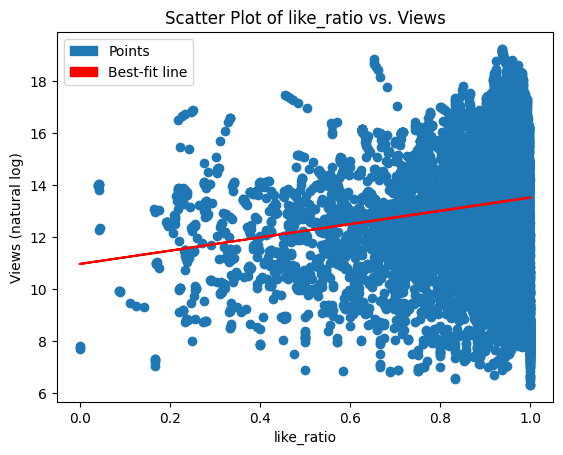

like_percent vs. views: r^2 = 0.001132507296626617


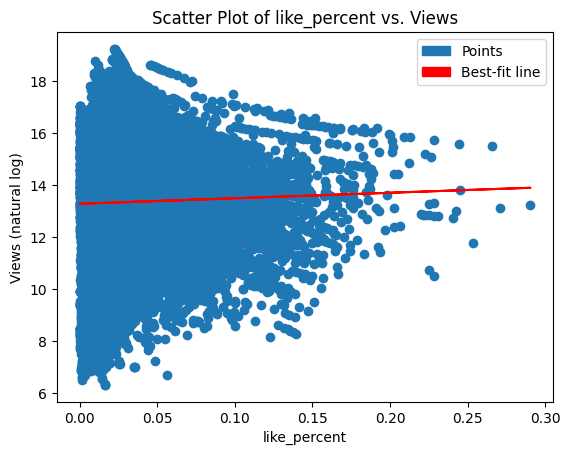

dislike_percent vs. views: r^2 = 0.0017121779001096904


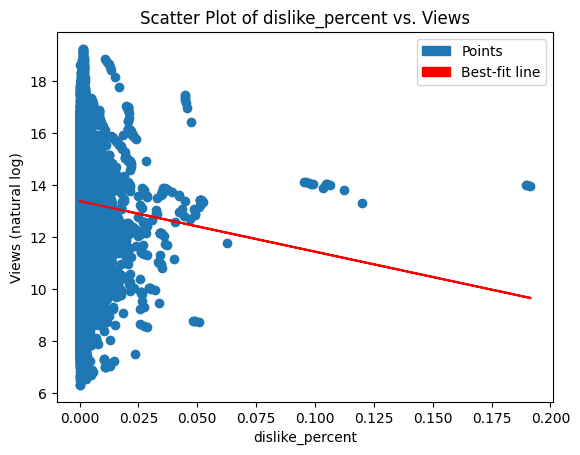

comment_percent vs. views: r^2 = 0.008616936576719691


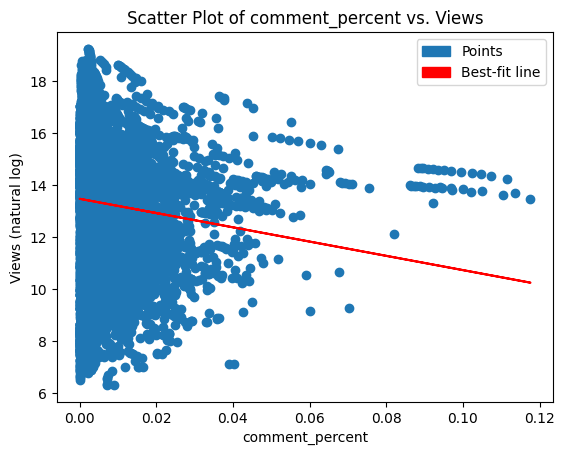

In [21]:
def plot_views(col):
  # fit a linear regression model
  model = LinearRegression()
  model.fit(pd.DataFrame(df[col]), pd.DataFrame(df['log_views']))
  views_pred = model.predict(pd.DataFrame(df[col]))

  # test the model, plot the points & line
  score = r2_score(df['log_views'], views_pred)
  print(f'{col} vs. views: r^2 = {score}')
  plt.scatter(df[col], df['log_views'])
  plt.plot(df[col], views_pred, color = 'red')

  plt.xlabel(col)
  plt.ylabel('Views (natural log)')
  plt.title(f'Scatter Plot of {col} vs. Views')
  plt.legend(handles = [Patch(color = 'C0', label = 'Points'), Patch(color = 'red', label = 'Best-fit line')])
  plt.show()

for col in ['like_ratio', 'like_percent', 'dislike_percent', 'comment_percent']:
  plot_views(col)

...not very good. The $r^2$ values are incredibly low and the lines don't visually fit the data at all. Clearly there's not much in terms of linear relationships. Let's try a bit more of a complex function... what about a neural network? Those are a lot better at finding complex relationships, and we'd be interested in seeing if any sort of relationship exists at all.

We'll start by prepping the data a bit, setting aside 20% of the videos for testing. An important note here - we *must* make sure that we don't have the same video in both the training and testing sets (since one video can appear multiple times). A simple way to guarantee this is to keep only one (e.g. the most recent) instance of each video.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# important!!!
# keep only the last (most recent) instance of each video
df = df.sort_values('trending_date').drop_duplicates(subset = ['video_id'], keep = 'last')

torch.manual_seed(22)

# split into training & test sets
X = df[['like_ratio', 'like_percent', 'dislike_percent', 'comment_percent']]
y = df['log_views']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
train_loader = DataLoader([[X_train[i], y_train[y_train.index[i]]] for i in range(len(X_train))], batch_size = 32, shuffle = True)
test_loader = DataLoader([[X_test[i], y_test[y_test.index[i]]] for i in range(len(X_test))], batch_size = 32, shuffle = True)

print(X_train.shape, X_test.shape)

feat_dim = 4

(4990, 4) (1248, 4)


Now we'll set up a neural network class for pytorch.

In [32]:
class MLPModel(nn.Module):
    def __init__(self, feat_dim):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(feat_dim, 5)
        self.fc2 = nn.Linear(5, 5)
        self.fc3 = nn.Linear(5, 6)
        self.fc4 = nn.Linear(6, 2)
        self.fc5 = nn.Linear(2, 1)

    def forward(self, x):
        r1 = F.relu(self.fc1(x))
        r2 = F.relu(self.fc2(r1))
        r3 = F.relu(self.fc3(r2))
        r4 = F.relu(self.fc4(r3))
        return self.fc5(r4)

model = MLPModel(feat_dim)

Then, we'll train it - using a basic setup of mean-squared error loss and the Adam optimizer.

In [33]:
# from hw5

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

epochs = 100
losses = []
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(torch.float32)
        targets = targets.to(torch.float32)

        optimizer.zero_grad()
        output = model(data).flatten()
        loss = criterion(output, targets)

        running_loss += loss.item()

        loss.backward()
        optimizer.step()
    running_loss /= len(train_loader)
    losses.append(running_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss}')

print('Finished Training')

Epoch 1/100, Loss: 169.044683211889
Epoch 2/100, Loss: 162.28524966117664
Epoch 3/100, Loss: 71.00431369512509
Epoch 4/100, Loss: 11.171721942913837
Epoch 5/100, Loss: 8.586130056625757
Epoch 6/100, Loss: 7.344859106418414
Epoch 7/100, Loss: 6.432612333542261
Epoch 8/100, Loss: 5.7313121648935175
Epoch 9/100, Loss: 5.255901204469876
Epoch 10/100, Loss: 4.870418890164449
Epoch 11/100, Loss: 4.49296003427261
Epoch 12/100, Loss: 4.2155338273598595
Epoch 13/100, Loss: 4.01575296658736
Epoch 14/100, Loss: 3.861399450363257
Epoch 15/100, Loss: 3.7342092050955844
Epoch 16/100, Loss: 3.6329347903911886
Epoch 17/100, Loss: 3.562216322391461
Epoch 18/100, Loss: 3.492569932570824
Epoch 19/100, Loss: 3.45191014959262
Epoch 20/100, Loss: 3.400480398764977
Epoch 21/100, Loss: 3.3560791252515254
Epoch 22/100, Loss: 3.3375534973083396
Epoch 23/100, Loss: 3.304951956638923
Epoch 24/100, Loss: 3.2768832315237093
Epoch 25/100, Loss: 3.2637187395340357
Epoch 26/100, Loss: 3.2472160779512844
Epoch 27/100, 

Train Loss: 3.051307100516099
Test Loss: 3.1268466283113527


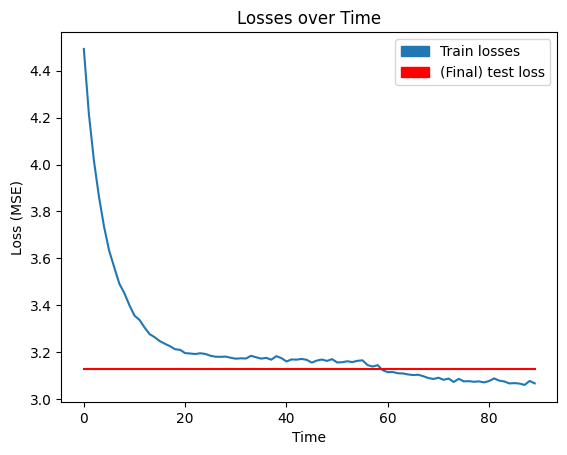

In [34]:
# from hw5

test_loss = 0.0
for batch_idx, (data, targets) in enumerate(test_loader):
    loss = criterion(model(data.to(torch.float32)).flatten(), targets.to(torch.float32))
    test_loss += loss.item()
test_loss = test_loss / len(test_loader)

train_loss = 0.0
for batch_idx, (data, targets) in enumerate(train_loader):
    loss = criterion(model(data.to(torch.float32)).flatten(), targets.to(torch.float32))
    train_loss += loss.item()
train_loss = train_loss / len(train_loader)

print("Train Loss:", train_loss)
print("Test Loss:", test_loss)

plt.plot(losses[10:]) # omit the first few cause they mess up the graph
plt.plot([test_loss for x in losses[10:]], color = 'red')
plt.title("Losses over Time")
plt.xlabel("Time")
plt.ylabel("Loss (MSE)")
plt.legend(handles = [Patch(color = 'C0', label = 'Train losses'), Patch(color = 'red', label = '(Final) test loss')])
plt.show()

Awesome! We see a few things:

*   The loss improved over time and remained similar even on the testing data, meaning the model was able to improve with more and more training.
*   The mean squared error of $\ln(\text{views})$ is about $3.127$, meaning the margin of error is *approximately* a factor of $e^\sqrt{3.127} \approx 5.861$ per video. This is a wide range, but it means we can roughly predict the number of digits in the view count $\pm 1$, which is not terrible given the exponential nature of YT.
*   Combining these, there does seem to be an (albeit complex) relationship between these numerical factors and view count/success, and these factors are *somewhat* predictors of video success. Of course, there are many more factors that can't be expressed in this dataset (hidden factors like view duration and how often people click on the video), but reaching any relationship at all is good for an enigmatic pursuit like YT.

We should note that even if we've found a relationship, it's just a correlation so far. All we can say is that more successful videos tend to have better ratios, which is expected, as more successful videos tend to be better videos and thus are likely to be better in all metrics. It's hard to tell just from this whether a video should *optimize* for these metrics (i.e. explicitly try to improve the like ratio/get viewers to comment), and likely requires more (possibly hidden) data.

For fun, let's look into one more thing. Are there any "hidden gems" among categories - i.e. categories with a lot of views but relatively few creators/videos? These may signal good categories to try to carve out an audience in. It's hard to tell this just from the trending videos, but we can try to approximate.

Recall that we removed duplicate videos before - we will keep this change, since we're mostly interested in distinct videos for this.

In [26]:
# collect view count & views per category
cat_counts = df.groupby('category_id')['category_id'].count().rename('count')
cat_views = df.groupby('category_id')['views'].mean().rename('views')
cat_df = pd.DataFrame({'count': cat_counts, 'views': cat_views})
cat_df

,count,views
category_id,,
Autos & Vehicles,69,1.484269e+06
Comedy,543,1.425121e+06
Education,248,6.148777e+05
Entertainment,1589,1.726437e+06
Film & Animation,314,2.582082e+06
Gaming,101,2.335621e+06
Howto & Style,593,9.378191e+05
Music,796,6.024251e+06
News & Politics,472,4.328779e+05


Let's plot (average) views vs. video count, and look into linear regression for it.

Count vs. views: r^2 = 0.06258841715552466


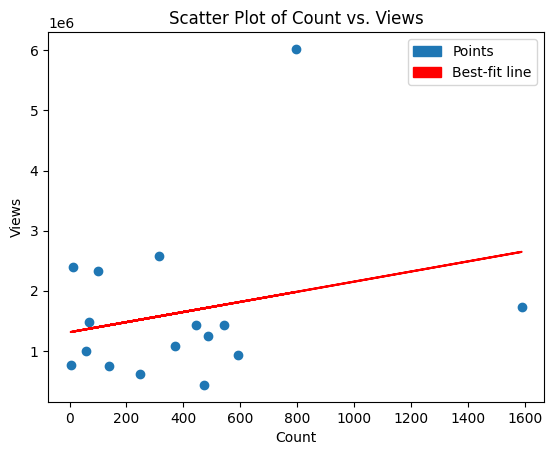

In [27]:
# fit a linear regression model
model = LinearRegression()
model.fit(pd.DataFrame(cat_df['count']), pd.DataFrame(cat_df['views']))
views_pred = model.predict(pd.DataFrame(cat_df['count']))

# test the model, plot the points & line
score = r2_score(cat_df['views'], views_pred)
print(f'Count vs. views: r^2 = {score}')
plt.scatter(cat_df['count'], cat_df['views'])
plt.plot(cat_df['count'], views_pred, color = 'red')

plt.xlabel('Count')
plt.ylabel('Views')
plt.title(f'Scatter Plot of Count vs. Views')
plt.legend(handles = [Patch(color = 'C0', label = 'Points'), Patch(color = 'red', label = 'Best-fit line')])
plt.show()

The actual result of the linear regression is not so interesting given how limited our data is, but the categories above the line (with higher views than predicted) are potentially interesting. Let's isolate them and look into them:

In [28]:
good_cats = cat_df[cat_df['views'] >= views_pred.flatten()]
good_cats.sort_values('count')

,count,views
category_id,,
Nonprofits & Activism,13,2.389424e+06
Autos & Vehicles,69,1.484269e+06
Gaming,101,2.335621e+06
Film & Animation,314,2.582082e+06
Music,796,6.024251e+06


...and now we have a list of categories potentially worth looking into further. Awesome!

# Insights & Conclusions

From this analysis, we found a lot of things - viewers among different countries gravitate toward different types (categories) of videos, a large variety of channels trend, channels more frequently trending don't necessarily have more views (!), there's a complex but seemingly existing relationship between engagement statistics (likes, dislikes, comments) and views, and we also found some high-view categories potentially worth looking into for creating a channel about (nonprofits & activism, autos & vehicles, gaming, film & animation, and music).

We also employed a variety of techniques - correlation analysis & linear regression, boxplot/histogram analysis for frequency data, a chi-squared hypothesis test, and a neural network to look for a more complex relationship in the numerical data.

That said, many of the conclusions were limited, as our data was limited. It's hard to really describe the relationship between engagement and views, and we likely need a more exhaustive set of video metadata (more than what was present in the dataset) to reach any decisive conclusions. What this means is there is no clear strategy such as "optimize the like ratio" to directly boost viewership, and the most straightforward strategy of "make videos as interesting as possible (and the rest will follow)" seems to have more merit.

However, having a model representing this relationship with decent accuracy allows us to predict the view count of a video just from its metadata. Extending this model to have more types of inputs (possibly the title/description, thumbnail, transcript, and, on a powerful enough computer, the *video itself*) would allow for evaluating a video, or merely an idea for a video, before much significant effort is put into its creation, which can massively increase a creator's efficiency and portion of videos that are highly successful.

To extend this analysis, one could do many things. For example, we could re-gather the data from more modern dates (e.g. this year) to get a more updated sample of the data, since YT changes a lot over time (which would be necessary to draw any *certain* conclusions about the YT landscape today). We could also look into the other (categorical, text, image) forms of data in the dataset and try to analyze those as well. We could also look into other datasets, potentially including the private (only visible via channel analytics) values, such as view duration and click-through rate (what portion of people clicked on the video when it was recommended), to try to find even stronger relationships.